# Weighted Least Squares

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.api as sm
from statsmodels.iolib.table import SimpleTable, default_txt_fmt

np.random.seed(1024)

## WLS Estimation

### Artificial data: Heteroscedasticity 2 groups 

Model assumptions:

 * Misspecification: true model is quadratic, estimate only linear
 * Independent noise/error term
 * Two groups for error variance, low and high variance groups

In [3]:
nsample = 50
x = np.linspace(0, 20, nsample)
X = np.column_stack((x, (x - 5) ** 2))
X = sm.add_constant(X)
beta = [5.0, 0.5, -0.01]
sig = 0.5
w = np.ones(nsample)
w[nsample * 6 // 10 :] = 3
y_true = np.dot(X, beta)
e = np.random.normal(size=nsample)
y = y_true + sig * w * e
X = X[:, [0, 1]]

### WLS knowing the true variance ratio of heteroscedasticity

In this example, `w` is the standard deviation of the error.  `WLS` requires that the weights are proportional to the inverse of the error variance.

In [4]:
mod_wls = sm.WLS(y, X, weights=1.0 / (w**2))
res_wls = mod_wls.fit()
print(res_wls.summary())

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.927
Model:                            WLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     613.2
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           5.44e-29
Time:                        07:32:19   Log-Likelihood:                -51.136
No. Observations:                  50   AIC:                             106.3
Df Residuals:                      48   BIC:                             110.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2469      0.143     36.790      0.0

## OLS vs. WLS

Estimate an OLS model for comparison: 

In [5]:
res_ols = sm.OLS(y, X).fit()
print(res_ols.params)
print(res_wls.params)

[5.24256099 0.43486879]
[5.24685499 0.44658241]


Compare the WLS standard errors to  heteroscedasticity corrected OLS standard errors:

In [6]:
se = np.vstack(
    [
        [res_wls.bse],
        [res_ols.bse],
        [res_ols.HC0_se],
        [res_ols.HC1_se],
        [res_ols.HC2_se],
        [res_ols.HC3_se],
    ]
)
se = np.round(se, 4)
colnames = ["x1", "const"]
rownames = ["WLS", "OLS", "OLS_HC0", "OLS_HC1", "OLS_HC2", "OLS_HC3"]
tabl = SimpleTable(se, colnames, rownames, txt_fmt=default_txt_fmt)
print(tabl)

          x1   const 
---------------------
WLS     0.1426  0.018
OLS     0.2707 0.0233
OLS_HC0  0.194 0.0281
OLS_HC1  0.198 0.0287
OLS_HC2 0.2003  0.029
OLS_HC3  0.207   0.03
---------------------


Calculate OLS prediction interval:

In [7]:
pred_ols = res_ols.get_prediction()
iv_l_ols = pred_ols.summary_frame()["obs_ci_lower"]
iv_u_ols = pred_ols.summary_frame()["obs_ci_upper"]

Draw a plot to compare predicted values in WLS and OLS:

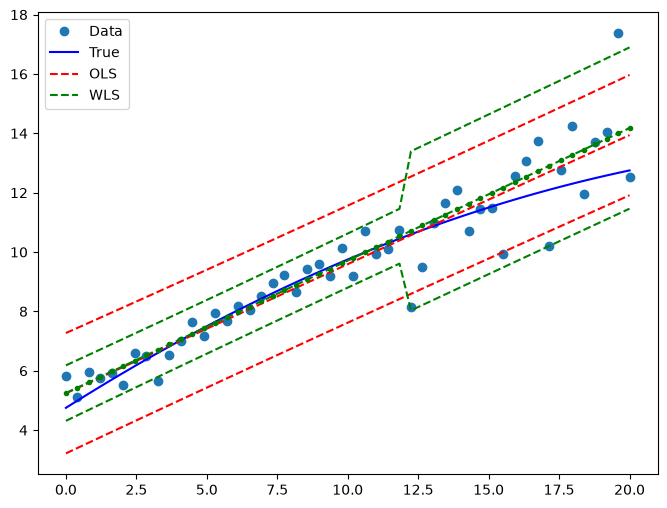

In [8]:
pred_wls = res_wls.get_prediction()
iv_l = pred_wls.summary_frame()["obs_ci_lower"]
iv_u = pred_wls.summary_frame()["obs_ci_upper"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x, y, "o", label="Data")
ax.plot(x, y_true, "b-", label="True")
# OLS
ax.plot(x, res_ols.fittedvalues, "r--")
ax.plot(x, iv_u_ols, "r--", label="OLS")
ax.plot(x, iv_l_ols, "r--")
# WLS
ax.plot(x, res_wls.fittedvalues, "g--.")
ax.plot(x, iv_u, "g--", label="WLS")
ax.plot(x, iv_l, "g--")
ax.legend(loc="best")

## Feasible Weighted Least Squares (2-stage FWLS)

Like `w`, `w_est` is proportional to the standard deviation, and so must be squared.

In [9]:
resid1 = res_ols.resid[w == 1.0]
var1 = resid1.var(ddof=int(res_ols.df_model) + 1)
resid2 = res_ols.resid[w != 1.0]
var2 = resid2.var(ddof=int(res_ols.df_model) + 1)
w_est = w.copy()
w_est[w != 1.0] = np.sqrt(var2) / np.sqrt(var1)
res_fwls = sm.WLS(y, X, 1.0 / (w_est**2)).fit()
print(res_fwls.summary())

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.931
Model:                            WLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     646.7
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.66e-29
Time:                        07:32:19   Log-Likelihood:                -50.716
No. Observations:                  50   AIC:                             105.4
Df Residuals:                      48   BIC:                             109.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2363      0.135     38.720      0.0